# Como começar usando

Antes de rodar crie um ambiente virtal e ative.  
Instalar o Poetry  
Executar o comando poetry lock  
Executar o comando poetry install  

# Imports

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import zscore
from collections import defaultdict
from sklearn.decomposition import PCA
import phik
from collections import defaultdict
import math
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


pds = pandas series  
df = DataFrame

# Preparando o Data Frame

In [2]:
abas  = pd.ExcelFile('WDI_EXCEL/WDIEXCEL.xlsx').sheet_names
abas

['Data', 'Country', 'Series', 'country-series', 'series-time', 'footnote']

In [3]:
metadata = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[2])
metadata.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,NaN,Annual,NaN,NaN,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Temporary fallow land refers to land left fall...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [4]:
metadata.columns = [col.strip().replace("_", " ") for col in metadata.columns]

In [5]:
metadata["Topic"].nunique()

88

In [6]:
lista_metadata = list(metadata["Topic"].unique())

In [7]:
metadata["Indicator Name"].nunique()

1496

In [8]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[0])
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [9]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [10]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [11]:
dados["Indicator Name"].nunique()

1496

In [12]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [13]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [14]:
dados_long.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object

## Separando por paises e comaçando a olhar o data frame do Brasil

Separação feita desta maneira para uma posssivel extrapolação para demais paises futuramente

In [15]:
paises_unicos = dados_long["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_long.groupby("Country Name")
}

brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
brasil.head()


Dados do Brasil:


,Indicator Name,Indicator Code,Year,Value
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# Analise do Brasil

## Explorando e preparando o data frame para analise

In [16]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
pds_br_tps = df_brasil_wide.dtypes
for i ,formato in pds_br_tps.items():
    if formato != 'float64' and formato != 'int64':
        print(i, formato)

In [18]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 64
Colunas: 1496
Total de valores nulos: 49579


### Verificando quantidade de nulos por indicador

In [19]:
# Contar valores nulos por linha
pds_nulos_por_indicador = df_brasil_wide.isna().sum(axis=0)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_indicador.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Indicator Name
Women who believe a husband is justified in beating his wife when she refuses sex with him (%)       64
Vitamin A supplementation coverage rate (% of children ages 6-59 months)                             64
Young people (ages 15-24) newly infected with HIV                                                    64
Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative)     64
Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative)    64
                                                                                                     ..
Terms of trade adjustment (constant LCU)                                                              0
Agriculture, forestry, and fishing, value added (constant 2015 US$)                                   0
Agriculture, forestry, and fishing, value added (constant LCU)                                        0
Agri

In [20]:
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadroes_sem_dados = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor == 64:
        indicadroes_sem_dados.append(indicador)
print(len(indicadroes_sem_dados))

102


In [21]:
new_df_brasil_wide = df_brasil_wide.drop(columns=indicadroes_sem_dados)
new_df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.768224e-13,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.446007e-13,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.748121e-13,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.508432e-13,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.247164e-12,NaN,NaN,NaN,NaN


In [22]:
# Substituir zeros por NaN (sem alterar o original ainda)
df_temp = new_df_brasil_wide.replace(0, np.nan)

# Contar valores nulos (incluindo os zeros que viraram NaN) por coluna
pds_nulos_por_indicador = df_temp.isna().sum(axis=0)

# Ordenar indicadores com mais "dados faltantes"
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)

# Selecionar indicadores com >= 30% de valores faltantes
limite = new_df_brasil_wide.shape[0] * 0.3  # 30% do total de anos (ex: 64)
indicadores_remover = [
    indicador for indicador, nulos in pds_nulos_por_indicador.items()
    if nulos >= limite
]

print(f"{len(indicadores_remover)} indicadores com >= 30% de NaNs ou Zeros")


911 indicadores com >= 30% de NaNs ou Zeros


In [23]:
new_df_brasil_wide = new_df_brasil_wide.drop(columns=indicadores_remover)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33399157.0,46.139,NaN,1.768224e-13,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35155579.0,47.122,5.125267,2.446007e-13,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,36971452.0,48.099,5.036272,3.748121e-13,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,38852223.0,49.078,4.961925,6.508432e-13,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40792376.0,50.059,4.872991,1.247164e-12,NaN


### Verificando quantidade de nulos por ano

In [24]:
# Contar valores nulos por linha
pds_nulos_por_ano = new_df_brasil_wide.isna().sum(axis=1)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_ano)

Quantidade de valores nulos por linha (ano):
Year
1960    257
1961    219
1962    205
1963    203
1964    202
       ... 
2019      6
2020      6
2021     31
2022     65
2023    133
Length: 64, dtype: int64


In [25]:
pds_nulos_por_ano = pds_nulos_por_ano.sort_values(ascending=False)
anos_remover = []
for indicador, valor in pds_nulos_por_ano.items():
    if valor >= (497*0.3):
        anos_remover.append(indicador)
print(len(anos_remover))

10


In [26]:
anos_remover.sort()
anos_remover

[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]

In [27]:
new_df_brasil_wide = new_df_brasil_wide.drop(labels=anos_remover, axis=0)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1970,NaN,3.291109e+11,3.782767e+10,NaN,3450.680697,396.617704,9.121553,3.806293e+09,3.599282,1.501929e+09,...,NaN,NaN,NaN,NaN,NaN,53323573.0,55.909,4.221541,5.881536e-12,31.250
1971,11.844305,3.680918e+11,4.418975e+10,9.139582,3766.058479,452.118667,9.018367,4.390516e+09,3.599282,1.752280e+09,...,NaN,NaN,NaN,NaN,NaN,55607782.0,56.894,4.194465,7.057843e-12,31.250
1972,12.509426,4.141380e+11,5.269725e+10,9.804705,4135.309393,526.200059,9.028985,5.243614e+09,3.599282,2.090295e+09,...,NaN,NaN,NaN,NaN,3.06,57963965.0,57.879,4.149837,8.369877e-12,31.250
1973,14.291462,4.733244e+11,7.074687e+10,11.557651,4613.254011,689.534076,9.501022,7.446978e+09,3.000000,2.351424e+09,...,NaN,NaN,NaN,NaN,2.78,60385804.0,58.855,4.093252,9.772397e-12,31.250
1974,6.152843,5.024473e+11,9.352216e+10,3.638966,4781.128777,889.927177,9.749445,1.017117e+10,3.599282,3.754972e+09,...,NaN,NaN,NaN,NaN,NaN,62870949.0,59.826,4.033015,1.262268e-11,28.125


In [28]:
colunas_preservadas = new_df_brasil_wide[['Population growth (annual %)', 'Population, total']].copy()

In [29]:
new_df_brasil_wide = new_df_brasil_wide.drop(colunas_preservadas, axis=1)

In [30]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 481 entries, Adjusted net national income (annual % growth) to Women Business and the Law Index Score (scale 1-100)
dtypes: float64(481)
memory usage: 203.3 KB


In [31]:
new_df_brasil_wide.describe()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
count,51.000000,5.200000e+01,5.200000e+01,51.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,5.200000e+01,...,49.000000,49.000000,49.000000,49.000000,45.000000,5.400000e+01,54.000000,54.000000,5.200000e+01,54.000000
mean,3.010929,9.162268e+11,6.681062e+11,1.425942,5590.578090,3682.081997,14.456639,1.461168e+11,4.417439,4.287812e+10,...,17.097469,19.294171,16.320850,18.161931,7.394556,1.256833e+08,75.951296,2.385401,5.155756e+01,57.060185
std,6.368678,3.304046e+11,5.915988e+11,6.130710,916.290481,2801.135806,3.945016,1.645337e+11,0.982101,4.571928e+10,...,9.433232,7.152482,9.000527,7.024541,3.469044,4.176731e+07,9.722235,1.177507,6.612087e+01,22.270061
min,-14.620223,3.291109e+11,3.782767e+10,-16.131683,3450.680697,396.617704,9.018367,3.806293e+09,2.800000,1.501929e+09,...,2.366505,6.648368,2.262181,5.898268,1.920000,5.332357e+07,55.909000,0.632380,5.881536e-12,28.125000
25%,-0.211241,6.445987e+11,1.925976e+11,-1.653632,4987.951719,1490.704292,11.792705,2.432008e+10,3.599282,7.718184e+09,...,7.535885,14.728987,7.253886,13.296869,4.040000,8.921814e+07,68.359000,1.201713,1.327366e-09,33.125000
50%,3.097826,9.307267e+11,4.434869e+11,1.276949,5542.382954,2537.679504,13.756643,7.698704e+10,4.264303,2.063184e+10,...,17.807276,19.942503,17.324395,18.475186,7.578000,1.301583e+08,78.675000,2.422724,2.191907e+01,50.625000
75%,5.882612,1.271165e+12,1.160585e+12,4.064897,6433.397369,5848.704142,15.720799,2.527057e+11,5.217500,8.456528e+10,...,23.862175,24.342780,22.045219,22.862175,10.150000,1.628768e+08,84.262250,3.513118,9.463679e+01,81.875000
max,22.522958,1.435186e+12,2.003637e+12,20.438679,7230.947942,10260.080844,23.062757,5.187513e+11,6.281311,1.399386e+11,...,39.869707,35.950176,39.080460,34.497130,13.697000,1.853562e+08,87.788000,4.221541,2.752110e+02,85.000000


### Verificando indicadores redundantes

In [32]:
import pandas as pd
import numpy as np

# Preencher NaNs (por exemplo com interpolação linear)
df = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Padronizar os dados
df_zscore = df.apply(zscore)

# Função para calcular a correlação cruzada entre duas séries
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    max_corr = max(corrs, key=abs)
    return max_corr

# Parâmetros
threshold = 0.9  # Correlação cruzada acima desse valor será considerada redundância
max_lag = 5      # Número máximo de anos de defasagem

# Detectar pares altamente correlacionados com defasagem
to_remove = set()
columns = df_zscore.columns.tolist()

for i, col1 in enumerate(columns):
    for col2 in columns[i+1:]:
        corr = max_cross_corr(df_zscore[col1], df_zscore[col2], max_lag=max_lag)
        if abs(corr) > threshold:
            to_remove.add(col2)

# Remover colunas redundantes
new_df_brasil_wide = df.drop(columns=to_remove)

print(f"\n{len(to_remove)} variáveis removidas por correlação cruzada.")

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
/home/pedro/Documentos/02


345 variáveis removidas por correlação cruzada.


###  Verificando df

In [33]:
new_df_brasil_wide = pd.concat([new_df_brasil_wide, colunas_preservadas], axis=1)

In [34]:
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: energy depletion (% of GNI),Adjusted savings: gross savings (% of GNI),Adjusted savings: mineral depletion (% of GNI),Adjusted savings: net national savings (% of GNI),Adjusted savings: net national savings (current US$),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Agricultural land (% of land area),...,Short-term debt (% of total external debt),Short-term debt (% of total reserves),Surface area (sq. km),Terms of trade adjustment (constant LCU),Total debt service (% of GNI),"Total debt service (% of exports of goods, services and primary income)",Travel services (% of commercial service exports),Travel services (% of commercial service imports),Population growth (annual %),"Population, total"
Year,,,,,,,,,,,,,,,,,,,,,
1970,11.844305,3.291109e+11,3.599282,0.047728,21.837114,0.178979,11.209303,1.367722e+10,75.066,22.771574,...,11.9318,60.006561,8515770.0,1.385222e+10,1.838590,43.829105,7.259714,17.629816,2.473172,95375651.0
1971,11.844305,3.680918e+11,3.599282,0.070111,21.837114,0.143288,11.209303,1.367722e+10,76.733,23.191045,...,11.9465,52.627887,8515770.0,1.067689e+10,1.805230,43.829105,7.259714,17.629816,2.448014,97739273.0
1972,12.509426,4.141380e+11,3.599282,0.066085,21.837114,0.165481,11.209303,1.367722e+10,79.207,23.610516,...,11.9275,33.541404,8515770.0,1.393160e+10,2.072381,43.829105,7.259714,17.629816,2.433363,100146797.0
1973,14.291462,4.733244e+11,3.000000,0.088562,21.837114,0.149967,11.209303,1.367722e+10,80.863,24.029988,...,11.9544,27.670790,8515770.0,2.787188e+10,2.453171,43.829105,7.259714,17.629816,2.421037,102600976.0
1974,6.152843,5.024473e+11,3.599282,0.388249,21.837114,0.217802,11.209303,1.367722e+10,81.322,24.449459,...,12.0278,49.458973,8515770.0,8.881354e+09,3.282392,43.829105,7.259714,17.629816,2.396659,105089675.0


In [35]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 138 entries, Adjusted net national income (annual % growth) to Population, total
dtypes: float64(138)
memory usage: 58.6 KB


In [36]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = new_df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = new_df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 54
Colunas: 138
Total de valores nulos: 0


# Análise Exploratória

## Agrupamento de topicos

### Topico com subtopico

In [37]:
# Filtra indicadores da metadata que estão no df_brasil_wide
metadata_filtered = metadata[metadata["Indicator Name"].isin(new_df_brasil_wide.columns)]

# Agrupa por tópico
agrupamentos_por_topico = (
    metadata_filtered.groupby("Topic")["Indicator Name"]
    .apply(list)
    .to_dict()
)


In [38]:
x = []
for topico in agrupamentos_por_topico.keys():
    z = []
    for item in agrupamentos_por_topico[topico]:
      z.append(item)
    x.append(len(z))
print(x)

[5, 3, 1, 2, 1, 8, 1, 11, 8, 8, 1, 3, 9, 2, 18, 1, 1, 2, 1, 1, 1, 6, 2, 4, 1, 3, 1, 2, 1, 9, 8, 3, 1]


In [39]:
# 3. Cria um dicionário de DataFrames por tópico
dfs_por_topico = {}

for topico, indicadores in agrupamentos_por_topico.items():
    # Garante que os indicadores existem no DataFrame
    indicadores_validos = [ind for ind in indicadores if ind in new_df_brasil_wide.columns]

    if indicadores_validos:
        df_topico = new_df_brasil_wide[indicadores_validos].copy()
        dfs_por_topico[topico] = df_topico


In [40]:
diagnostico_topico = []

for topico, df in dfs_por_topico.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent_corr = 0.0
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent_corr = round((n_corr_alta / total_possible) * 100, 2)
    except:
        per_cent_corr = None

    diagnostico_topico.append({
        'Topico': topico,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent_corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag = pd.DataFrame(diagnostico_topico).sort_values('Topico', ascending=True).reset_index(drop=True)
df_diag

,Topico,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt: Balance of payments: C...,5,54,0.0,0.0,5,0.07
1,Economic Policy & Debt: Balance of payments: C...,3,54,0.0,0.0,2,0.04
2,Economic Policy & Debt: Balance of payments: C...,1,54,0.0,0.0,0,0.00
3,Economic Policy & Debt: Balance of payments: C...,2,54,0.0,0.0,0,0.00
4,Economic Policy & Debt: Balance of payments: R...,1,54,0.0,0.0,1,0.02
5,Economic Policy & Debt: External debt: Debt ra...,8,54,0.0,0.0,3,0.06
6,Economic Policy & Debt: External debt: Debt se...,1,54,0.0,0.0,1,0.02
7,Economic Policy & Debt: External debt: Net flows,11,54,0.0,0.0,18,0.20
8,Economic Policy & Debt: National accounts: Adj...,8,54,0.0,0.0,5,0.06
9,Economic Policy & Debt: National accounts: Gro...,8,54,0.0,0.0,5,0.09


### Topicos macros

In [41]:
dfs_por_macrotema = defaultdict(list)

for topico, df in dfs_por_topico.items():
    macrotema = topico.split(':')[0].strip()
    dfs_por_macrotema[macrotema].append(df)


In [42]:
dfs_macrotema_unificado = {}

for macrotema, lista_dfs in dfs_por_macrotema.items():
    df_merged = pd.concat(lista_dfs, axis=1)
    # Remove colunas duplicadas (caso haja) e mantém ordem
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
    dfs_macrotema_unificado[macrotema] = df_merged

In [43]:
dfs_macrotema_unificado.pop("Education", None).head(0)

Indicator Name,Lower secondary school starting age (years),"Secondary education, duration (years)"
Year,,


In [44]:
diagnostico_macrotema = []

for tema, df in dfs_macrotema_unificado.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent__corr = 0.0  # Ou np.nan, dependendo do que quiser representar
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent__corr = round((n_corr_alta / total_possible) * 100, 2)

    except:
        per_cent__corr = None

    diagnostico_macrotema.append({
        'Macrotema': tema,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent__corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag_macro = pd.DataFrame(diagnostico_macrotema).sort_values('N_Variáveis', ascending=False)
df_diag_macro.reset_index(drop=True, inplace=True)
df_diag_macro


,Macrotema,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt,81,54,0.0,0.00,65,0.91
1,Private Sector & Trade,17,54,0.0,0.00,9,0.13
2,Environment,13,54,0.0,0.00,7,0.07
3,Financial Sector,8,54,0.0,0.00,12,0.11
4,Health,4,54,0.0,16.67,0,0.00
5,Public Sector,3,54,0.0,0.00,3,0.06
6,Social Protection & Labor,1,54,0.0,0.00,0,0.00


In [45]:
px.bar(df_diag_macro, x="Macrotema", y="N_Variáveis", title="Número de Variáveis por Macrotema")


## Analise de crescimento populacional

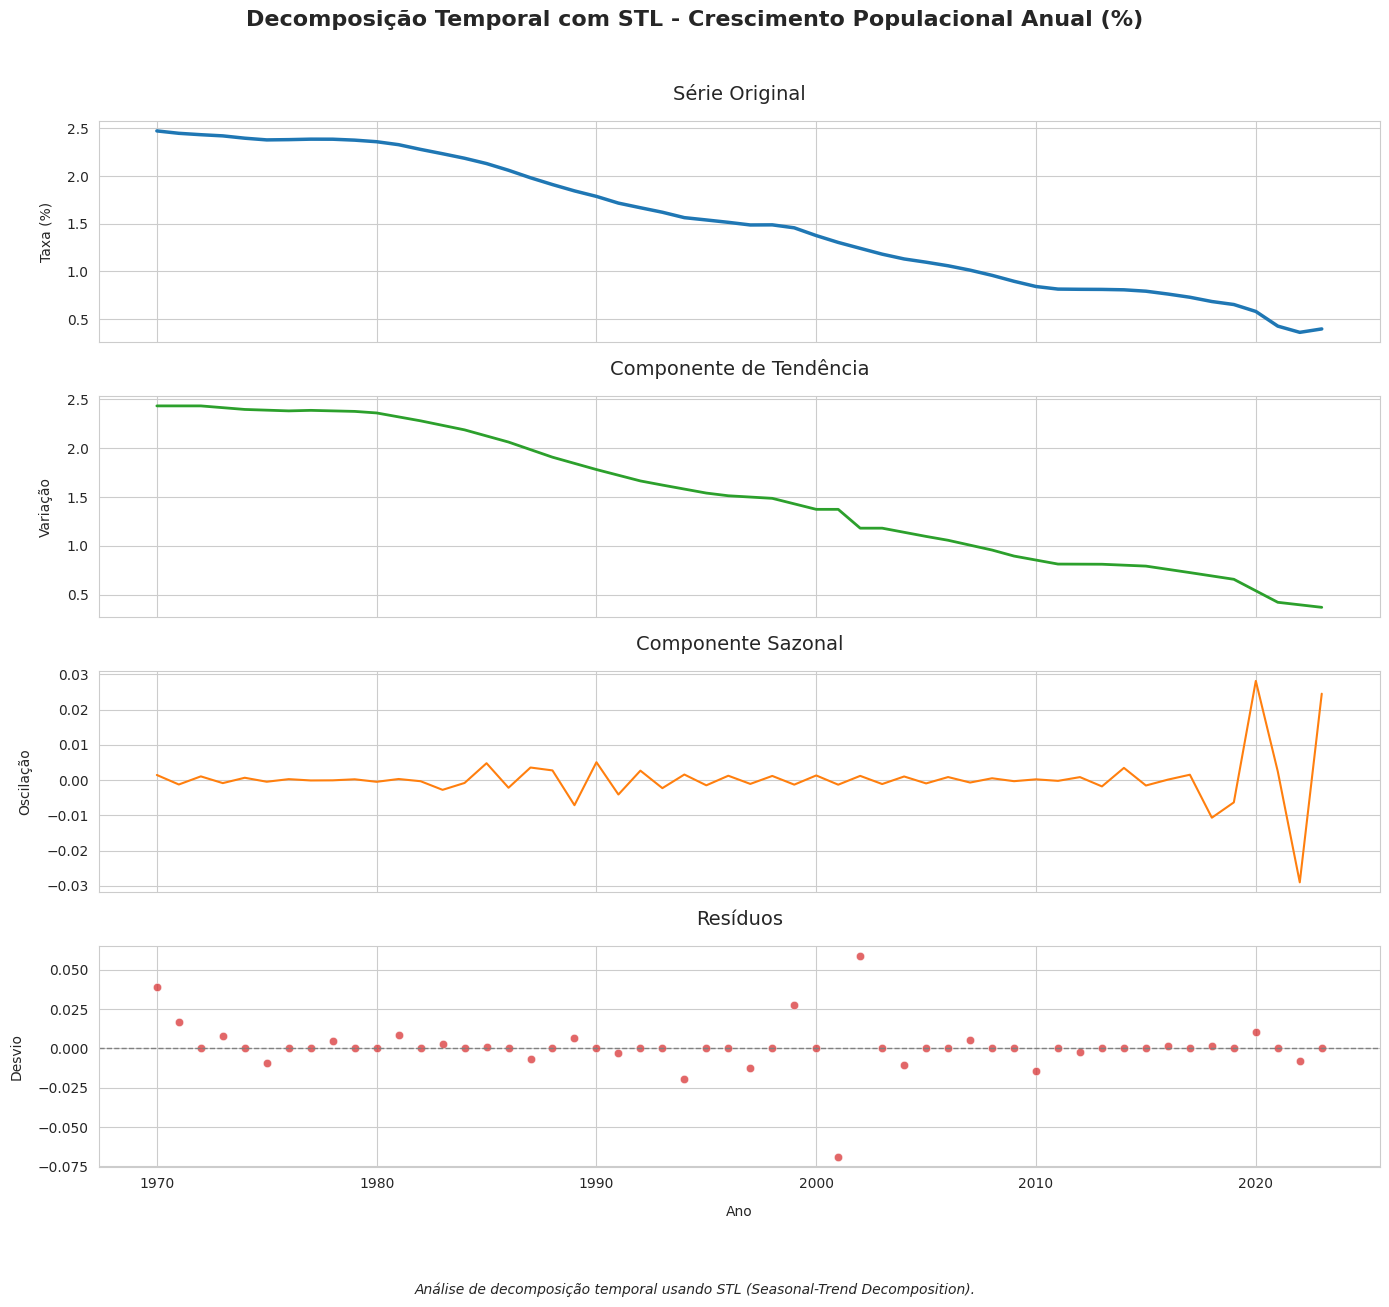

In [46]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo mais robusta
plt.style.use('default')  # Usa o estilo padrão como base
sns.set_style("whitegrid")  # Estilo do seaborn
sns.set_palette("husl")  # Paleta de cores
plt.rcParams['figure.facecolor'] = 'white'  # Fundo branco

# Interpolação
pop_growth = new_df_brasil_wide['Population growth (annual %)'].interpolate()

# Verifica se há dados suficientes
if len(pop_growth) >= 4:
    # STL: usa o Loess para detectar tendência e sazonalidade
    stl = STL(pop_growth, period=2, robust=True)
    res = stl.fit()
    
    # Criar figura
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Decomposição Temporal com STL - Crescimento Populacional Anual (%)', 
                 y=1.02, fontsize=16, fontweight='bold')
    
    # Série original
    sns.lineplot(x=pop_growth.index, y=pop_growth, ax=axes[0], linewidth=2.5, color='#1f77b4')
    axes[0].set_title('Série Original', pad=15, fontsize=14)
    axes[0].set_ylabel('Taxa (%)', labelpad=10)
    
    # Tendência
    sns.lineplot(x=res.trend.index, y=res.trend, ax=axes[1], linewidth=2, color='#2ca02c')
    axes[1].set_title('Componente de Tendência', pad=15, fontsize=14)
    axes[1].set_ylabel('Variação', labelpad=10)
    
    # Sazonalidade
    sns.lineplot(x=res.seasonal.index, y=res.seasonal, ax=axes[2], linewidth=1.5, color='#ff7f0e')
    axes[2].set_title('Componente Sazonal', pad=15, fontsize=14)
    axes[2].set_ylabel('Oscilação', labelpad=10)
    
    # Resíduos
    sns.scatterplot(x=res.resid.index, y=res.resid, ax=axes[3], color='#d62728', alpha=0.7)
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[3].set_title('Resíduos', pad=15, fontsize=14)
    axes[3].set_ylabel('Desvio', labelpad=10)
    axes[3].set_xlabel('Ano', labelpad=10)
    
    # Ajuste layout
    plt.tight_layout()
    plt.figtext(0.5, -0.05, 
                "Análise de decomposição temporal usando STL (Seasonal-Trend Decomposition).",
                ha="center", fontsize=10, style='italic')
    
    plt.show()

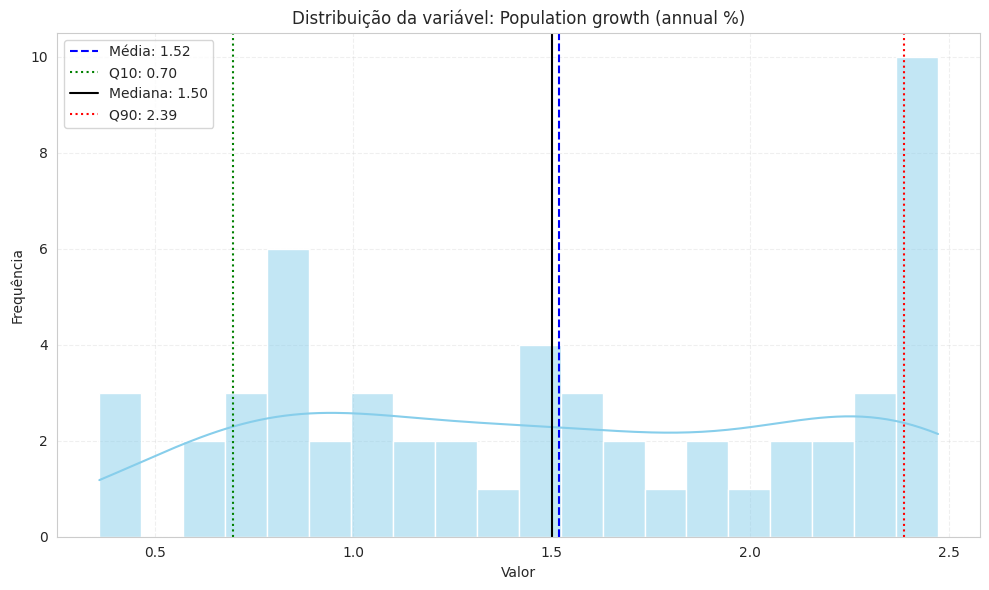

In [47]:
# Seleciona a variável
variavel = 'Population growth (annual %)'
serie = new_df_brasil_wide[variavel].dropna()

# Calcula estatísticas
media = serie.mean()
q10, mediana, q90 = np.percentile(serie, [10, 50, 90])
min_val, max_val = serie.min(), serie.max()

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(serie, kde=True, color='skyblue', bins=20)
plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(q10, color='green', linestyle=':', label=f'Q10: {q10:.2f}')
plt.axvline(mediana, color='black', linestyle='-', label=f'Mediana: {mediana:.2f}')
plt.axvline(q90, color='red', linestyle=':', label=f'Q90: {q90:.2f}')
plt.title(f'Distribuição da variável: {variavel}')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_101095/2557967588.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




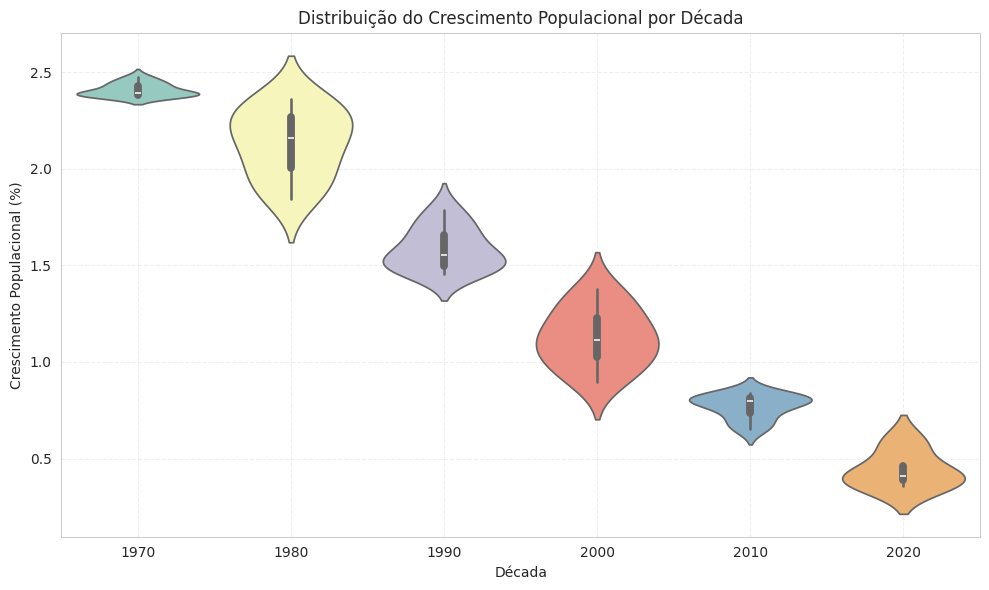

In [48]:
# Criar coluna de década
df_decada = new_df_brasil_wide.copy()
df_decada['Década'] = (df_decada.index // 10) * 10

# Plot para uma variável de interesse
plt.figure(figsize=(10, 6))
sns.violinplot(x='Década', y='Population growth (annual %)', data=df_decada.reset_index(), palette="Set3")
plt.title('Distribuição do Crescimento Populacional por Década')
plt.xlabel('Década')
plt.ylabel('Crescimento Populacional (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlações

Phik por item

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Land area (sq. km) for analysis 1. Dropping this column

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Lower secondary school starting age (years) for analysis 1. Dropping this column

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Renewable internal freshwater resources, total (billion cubic meters) for analysis 1. Dropping this column

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Secondary education, duration (years) for analysis 1. Dropping this column



interval columns not set, guessing: ['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money 

/tmp/ipykernel_101095/4049580031.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




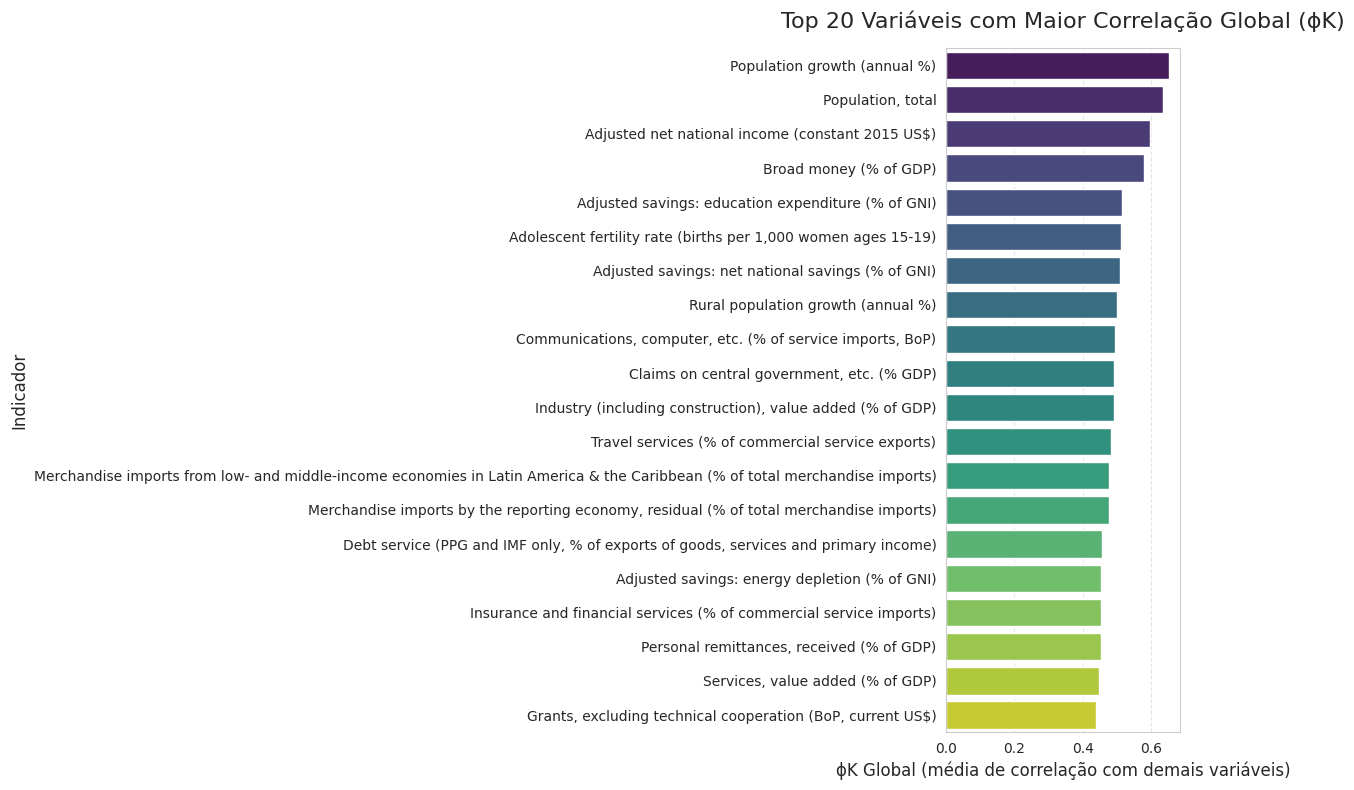

In [49]:
# Passo 1: interpolar valores faltantes
df_interp = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Passo 2: calcular matriz phik
phik_corr = df_interp.phik_matrix()

# Passo 3: calcular o vetor de correlação global (ϕK global)
phik_global = phik_corr.dropna(axis=0, how='all').mean(axis=1).sort_values(ascending=False)

# Passo 4: plotar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(y=phik_global.index[:20], x=phik_global.values[:20], palette='viridis')
plt.title('Top 20 Variáveis com Maior Correlação Global (ϕK)', fontsize=16, pad=15)
plt.xlabel('ϕK Global (média de correlação com demais variáveis)', fontsize=12)
plt.ylabel('Indicador', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

phik por macro tema

interval columns not set, guessing: ['Foreign direct investment, net outflows (% of GDP)', 'Net errors and omissions (BoP, current US$)', 'Reserves and related items (BoP, current US$)', 'Foreign direct investment, net inflows (% of GDP)', 'Portfolio equity, net inflows (BoP, current US$)', 'Current account balance (BoP, current US$)', 'Current account balance (% of GDP)', 'Net trade in goods (BoP, current US$)', 'Communications, computer, etc. (% of service imports, BoP)', 'Net secondary income (BoP, current US$)', 'Personal remittances, received (% of GDP)', 'Grants, excluding technical cooperation (BoP, current US$)', 'External debt stocks (% of GNI)', 'Short-term debt (% of total reserves)', 'Short-term debt (% of exports of goods, services and primary income)', 'Short-term debt (% of total external debt)', 'Total debt service (% of exports of goods, services and primary income)', 'Total debt service (% of GNI)', 'Public and publicly guaranteed debt service (% of GNI)', 'Multilater

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Renewable internal freshwater resources, total (billion cubic meters) for analysis 1. Dropping this column

/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning:

Not enough unique value for variable Land area (sq. km) for analysis 1. Dropping this column

/tmp/ipykernel_101095/1030460313.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




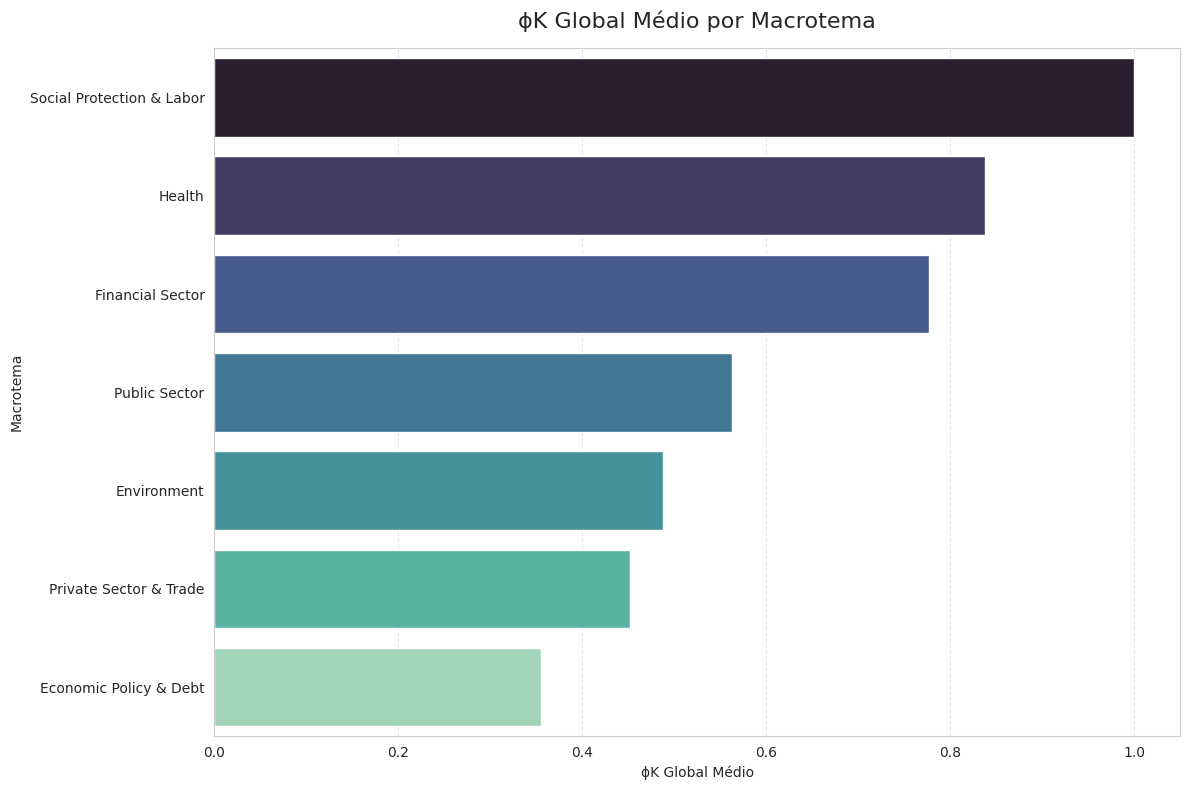

In [50]:
# Armazenar resultados
phik_macrotemas = {}

for tema, df in dfs_macrotema_unificado.items():
    # Interpola para preencher valores ausentes
    df_interp = df.interpolate(method='linear', limit_direction='both')

    try:
        # Calcula a matriz de correlação ϕK
        phik_corr = df_interp.phik_matrix()

        # Calcula o ϕK global (média das correlações de cada variável com as outras)
        phik_global_medio = phik_corr.dropna(axis=0, how='all').mean().mean()
        phik_macrotemas[tema] = phik_global_medio

    except Exception as e:
        print(f"Erro no macrotema '{tema}': {e}")

# Converter para DataFrame
phik_df = pd.DataFrame.from_dict(phik_macrotemas, orient='index', columns=['ϕK Global Médio'])
phik_df.sort_values('ϕK Global Médio', ascending=False, inplace=True)

# Plotar gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x=phik_df['ϕK Global Médio'], y=phik_df.index, palette='mako')
plt.title('ϕK Global Médio por Macrotema', fontsize=16, pad=15)
plt.xlabel('ϕK Global Médio')
plt.ylabel('Macrotema')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pear por itens

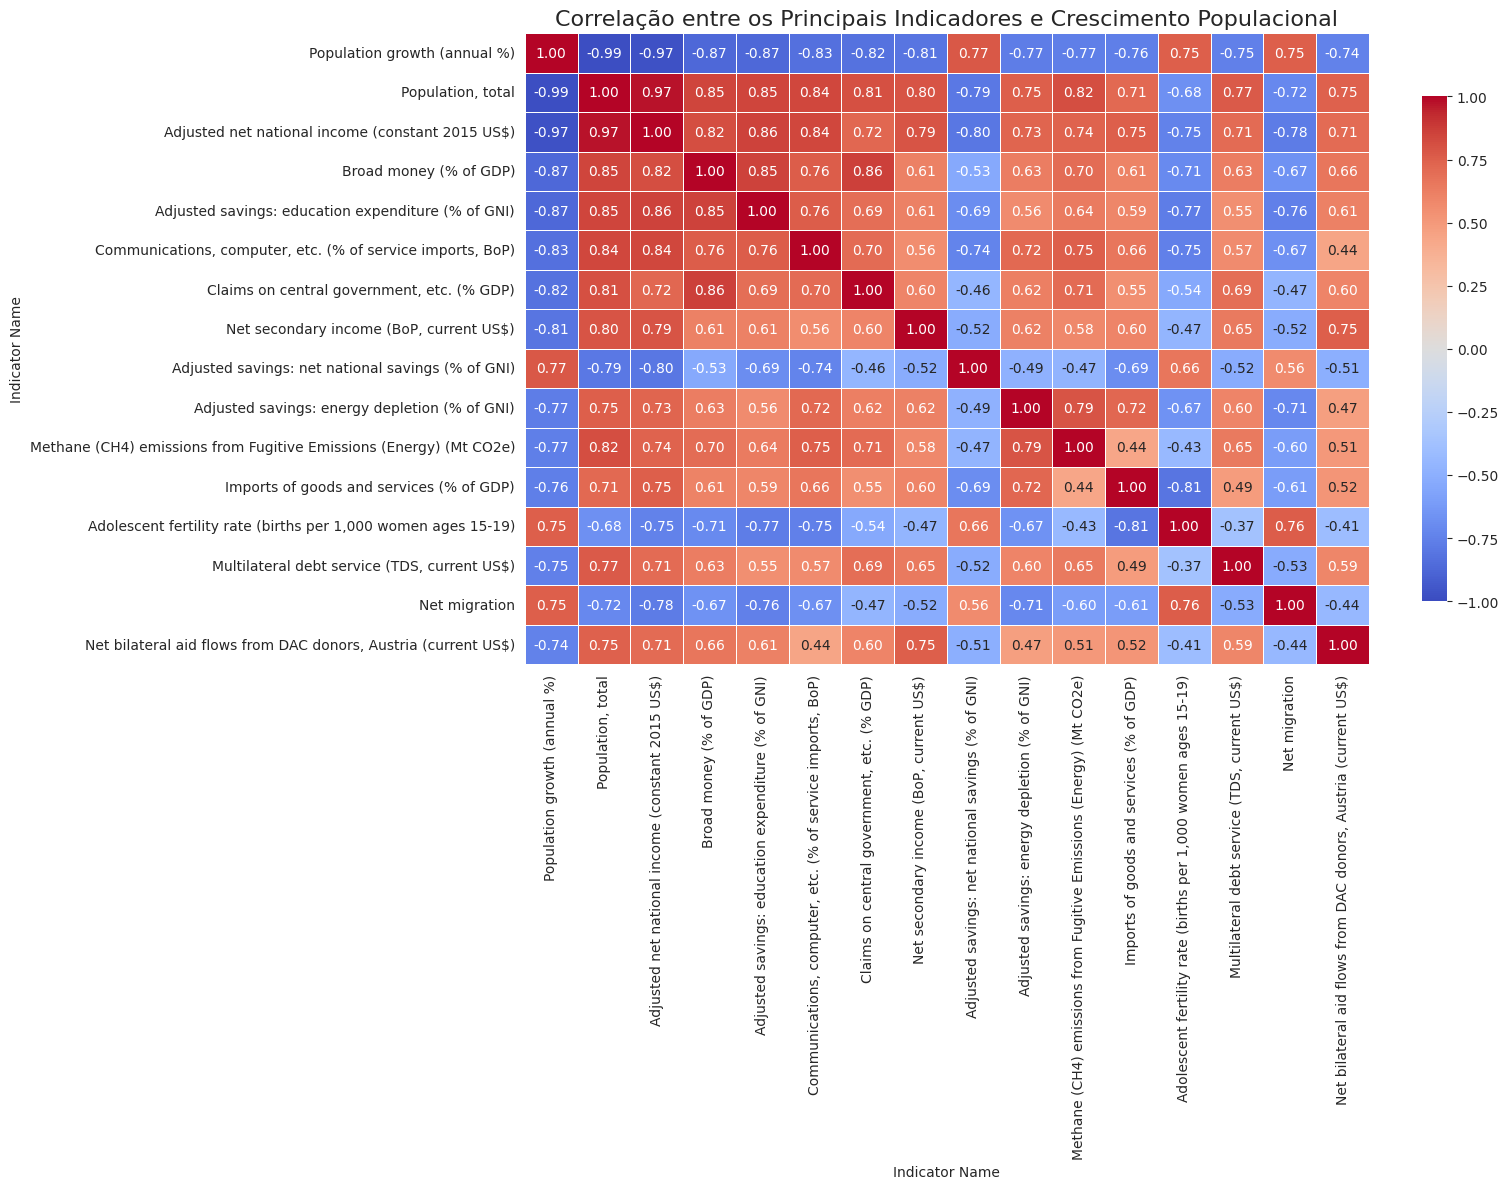

In [51]:
# 1. Análise de Correlação Avançada
plt.figure(figsize=(16, 12))
# Selecionando os 15 indicadores mais correlacionados com crescimento populacional
corr_pop = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)
top_15_vars = corr_pop.head(16).index
corr_matrix = new_df_brasil_wide[top_15_vars].corr()

# Máscara para triângulo superior
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlação entre os Principais Indicadores e Crescimento Populacional', fontsize=16)
plt.tight_layout()
plt.show()

pearson por macro

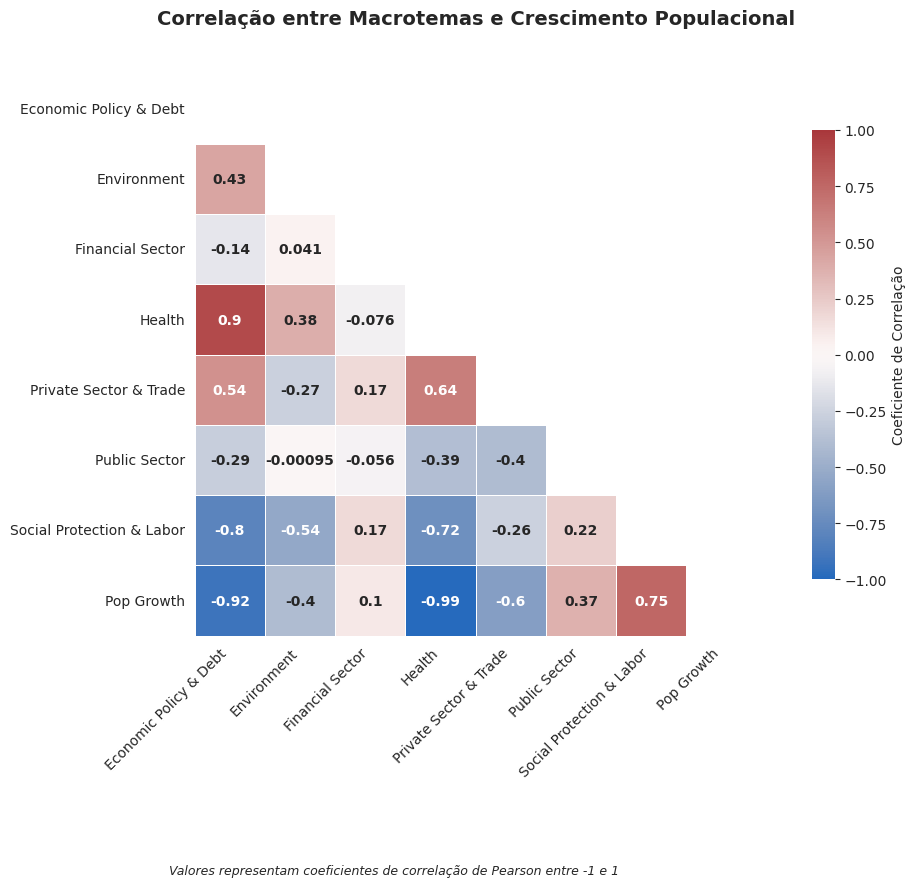

In [52]:
medias_macro = {}
for macrotema, df_macro in dfs_macrotema_unificado.items():
    df_macro_interp = df_macro.interpolate(method='linear', limit_direction='both')
    medias_macro[macrotema] = df_macro_interp.mean(axis=1)

df_macro_medias = pd.DataFrame(medias_macro)
df_macro_medias['Pop Growth'] = new_df_brasil_wide['Population growth (annual %)']
# Configurações de estilo
plt.style.use('default')
sns.set_style("white")
plt.rcParams['figure.facecolor'] = 'white'

# Criar a figura
plt.figure(figsize=(12, 8))

# Gerar a máscara para o triângulo superior (opcional)
mask = np.triu(np.ones_like(df_macro_medias.corr(), dtype=bool))

# Heatmap aprimorado
heatmap = sns.heatmap(
    df_macro_medias.corr(),
    mask=mask,  # Remover se quiser mostrar toda a matriz
    annot=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    cmap='vlag',  # Alternativa: 'coolwarm', 'RdBu_r', 'icefire'
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'}
)

# Melhorar título
plt.title(
    "Correlação entre Macrotemas e Crescimento Populacional\n",
    fontsize=14,
    pad=20,
    fontweight='bold'
)

# Rotacionar os rótulos do eixo x
heatmap.set_xticklabels(
    heatmap.get_xticklabels(),
    rotation=45,
    horizontalalignment='right',
    fontsize=10
)

# Ajustar rótulos do eixo y
heatmap.set_yticklabels(
    heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# Adicionar grade de referência (opcional)
heatmap.grid(False)

# Ajustar layout
plt.tight_layout()

# Adicionar nota de rodapé
plt.figtext(
    0.5, -0.1,
    "Valores representam coeficientes de correlação de Pearson entre -1 e 1",
    ha="center",
    fontsize=9,
    style='italic'
)

plt.show()



## Principais correlações com o crescimento populacional

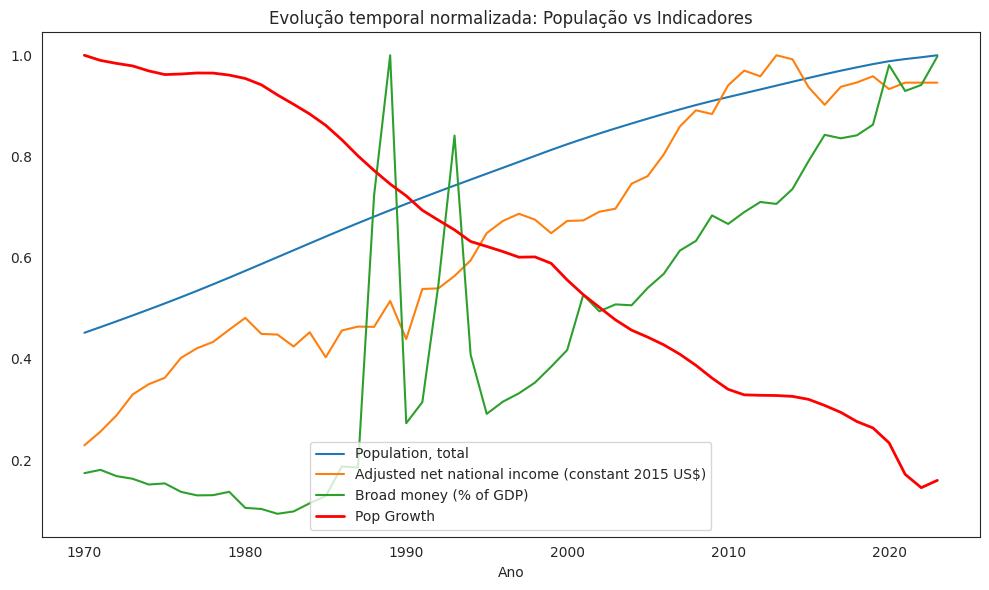

In [53]:
plt.figure(figsize=(10, 6))

# Seleciona as 3 variáveis mais correlacionadas com o crescimento populacional
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:4]

# Normaliza os indicadores pela escala máxima
for var in top_k.index:
    plt.plot(new_df_brasil_wide.index, new_df_brasil_wide[var] / new_df_brasil_wide[var].max(), label=var)

plt.plot(new_df_brasil_wide.index, new_df_brasil_wide['Population growth (annual %)'] / new_df_brasil_wide['Population growth (annual %)'].max(),
         label='Pop Growth', linewidth=2, color='red')

plt.legend()
plt.title("Evolução temporal normalizada: População vs Indicadores")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()



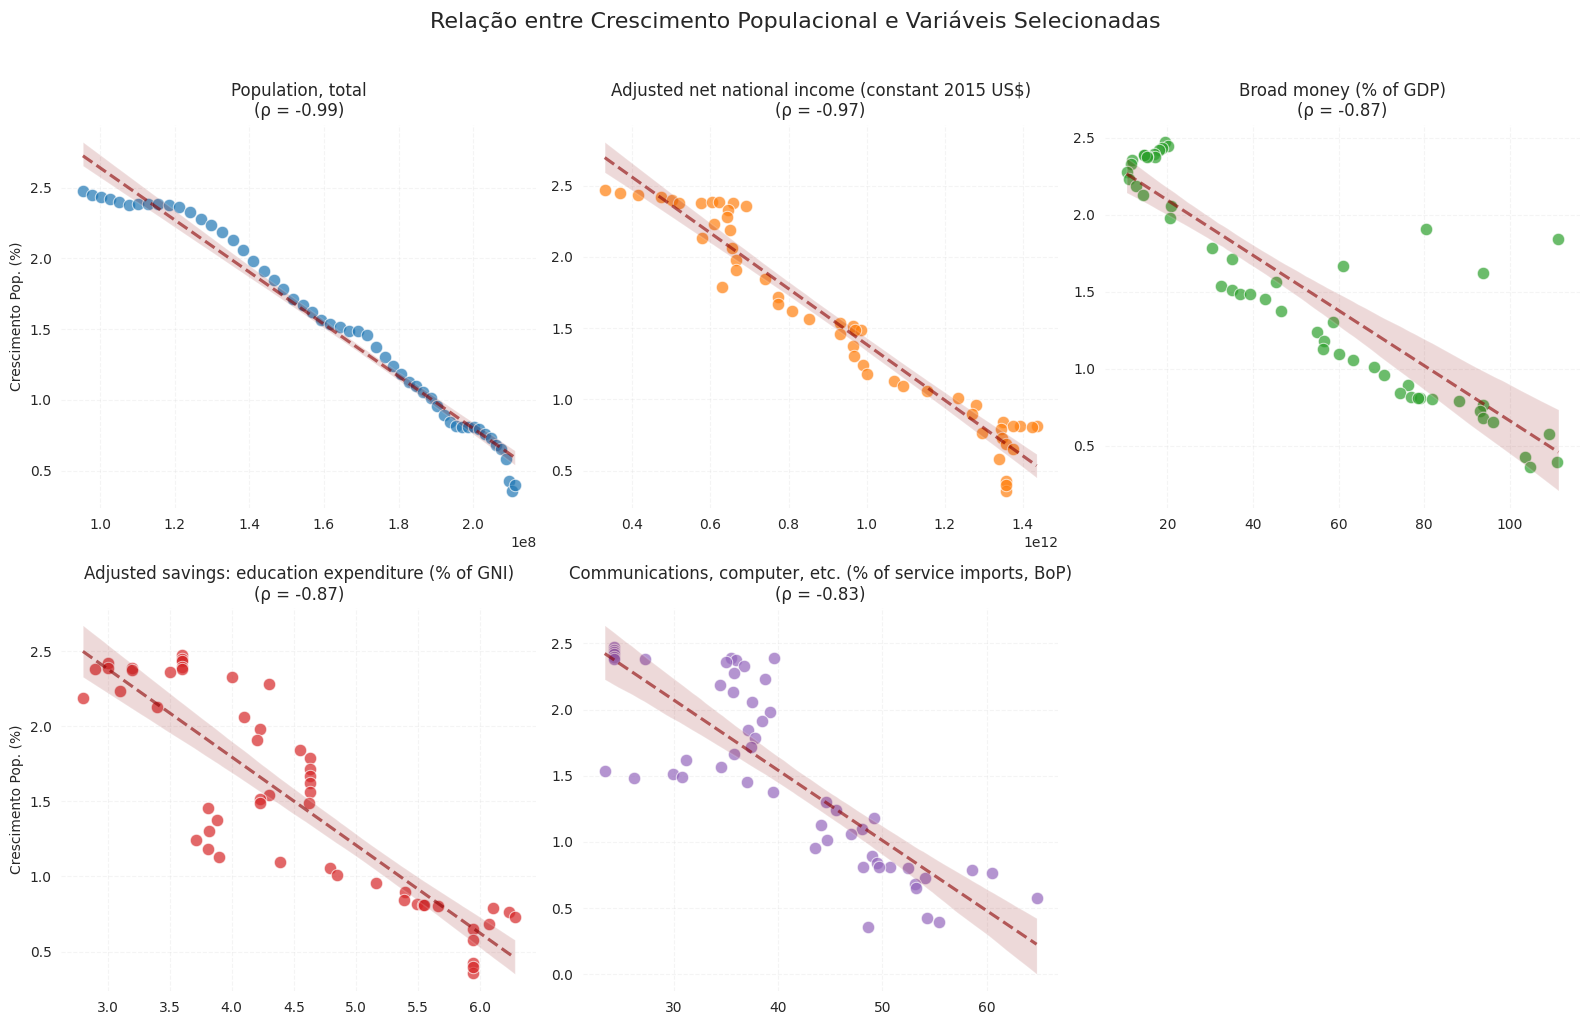

In [54]:
top_k = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)[1:6]

# Configurar a figura com subplots
plt.figure(figsize=(16, 10), facecolor='white')
plt.suptitle('Relação entre Crescimento Populacional e Variáveis Selecionadas', y=1.02, fontsize=16)

# Criar um subplot para cada variável
for i, var in enumerate(top_k.index, 1):
    plt.subplot(2, 3, i)  # 2 linhas, 3 colunas

    # Scatterplot
    ax = sns.scatterplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        color=plt.cm.tab10(i-1),  # Cores diferentes para cada variável
        s=80,
        alpha=0.7
    )

    # Linha de regressão
    sns.regplot(
        data=new_df_brasil_wide,
        x=var,
        y='Population growth (annual %)',
        scatter=False,
        color='darkred',
        line_kws={'linestyle':'--', 'alpha':0.6}
    )

    # Adicionar título e coeficiente de correlação
    corr = new_df_brasil_wide.corr().loc[var, 'Population growth (annual %)']
    plt.title(f'{var}\n(ρ = {corr:.2f})', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Crescimento Pop. (%)' if i == 1 or i == 4 else '', fontsize=10)

    # Grid e estilo
    plt.grid(True, linestyle='--', alpha=0.2)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Pré Processamento

Para a taxa de crescimento populacional eu não usaria

## Agrupamentos por PCA

### Fuções para criação do PCA e para comparar variancia

In [55]:
def realizar_pca_macrotemas(dfs_macrotema_unificado):
    """
    Realiza PCA para cada macrotema e gera visualizações.
    
    Args:
        dfs_macrotema_unificado: Dicionário contendo dataframes por macrotema
    """
    # Dicionário para armazenar resultados do PCA
    pca_resultados = {}
    
    # Número máximo de componentes a considerar
    max_componentes = 3
    
    # Para cada macrotema
    for macrotema, df in dfs_macrotema_unificado.items():
        print(f"\n## Analisando macrotema: {macrotema}")
        
        # Interpolar valores faltantes
        df_interpolado = df.interpolate(method='linear', limit_direction='both')
        
        # Verificar se existem dados suficientes
        if df_interpolado.shape[0] < 2 or df_interpolado.shape[1] < 2:
            print(f"Dados insuficientes para o macrotema {macrotema}")
            continue
        
        # Padronização (z-score)
        scaler = StandardScaler()
        df_scaled = pd.DataFrame(
            scaler.fit_transform(df_interpolado),
            index=df_interpolado.index,
            columns=df_interpolado.columns
        )
        
        # Determinar número de componentes
        n_componentes = min(df_scaled.shape[1], max_componentes)
        
        try:
            # Aplicar PCA
            pca = PCA(n_components=n_componentes)
            pca_result = pca.fit_transform(df_scaled)
            
            # Criar DataFrame com resultados
            df_pca = pd.DataFrame(
                pca_result,
                index=df_scaled.index,
                columns=[f'PC{i+1}' for i in range(n_componentes)]
            )
            
            # Armazenar resultados
            pca_resultados[macrotema] = {
                'pca': pca,
                'df_pca': df_pca,
                'variancia_explicada': pca.explained_variance_ratio_,
                'loadings': pd.DataFrame(
                    pca.components_.T,
                    index=df_scaled.columns,
                    columns=[f'PC{i+1}' for i in range(n_componentes)]
                )
            }
            
            print(f"  ✓ PCA realizado com sucesso: {n_componentes} componentes")
            print(f"  ✓ Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")
            
        except Exception as e:
            print(f"Erro ao realizar PCA para {macrotema}: {e}")
    
    return pca_resultados

In [56]:
def plotar_variancias_explicadas(pca_resultados):
    """
    Gera gráficos de barras para a variância explicada por cada componente principal, organizados 3 a 3.
    """
    temas = list(pca_resultados.keys())
    total = len(temas)
    cols = 3
    rows = math.ceil(total / cols)

    fig = make_subplots(
        rows=rows, 
        cols=cols,
        subplot_titles=[f"Variância Explicada - {tema}" for tema in temas],
        vertical_spacing=0.15,
        horizontal_spacing=0.1
    )
    
    cores = px.colors.qualitative.Plotly
    
    for idx, (tema, resultado) in enumerate(pca_resultados.items()):
        row = idx // cols + 1
        col = idx % cols + 1

        variancias = resultado['variancia_explicada']
        variancia_cumulativa = np.cumsum(variancias)
        
        fig.add_trace(
            go.Bar(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancias * 100,
                name=f"{tema} - Individual",
                marker_color=cores[idx % len(cores)],
                opacity=0.7,
                showlegend=False
            ),
            row=row, col=col
        )
        
        fig.add_trace(
            go.Scatter(
                x=[f'PC{j+1}' for j in range(len(variancias))],
                y=variancia_cumulativa * 100,
                mode='lines+markers',
                name=f"{tema} - Cumulativa",
                marker=dict(color='red'),
                line=dict(width=2),
                showlegend=False
            ),
            row=row, col=col
        )

        fig.add_shape(
            type='line',
            x0=-0.5,
            x1=len(variancias)-0.5,
            y0=75,
            y1=75,
            line=dict(color='green', width=1, dash='dash'),
            row=row, col=col
        )
    
    fig.update_layout(
        height=350 * rows,
        width=1000,
        title_text="Variância Explicada por Componentes Principais",
        showlegend=False
    )
    
    fig.update_yaxes(title_text="Variância Explicada (%)", range=[0, 105])
    fig.update_xaxes(title_text="Componentes Principais")
    
    return fig

### Analise de PCA

In [57]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 45.70%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 62.16%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


Removeremos Variaveis dos grupos que não atingiram uma boa Variancia Explicada por 3 grupos

In [58]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Economic Policy & Debt"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Economic Policy & Debt"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")



66 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [59]:
from scipy.stats import zscore

# Preencher e padronizar
df = dfs_macrotema_unificado["Private Sector & Trade"].interpolate(method='linear', limit_direction='both')
df_zscore = df.apply(zscore)
crescimento_zscore = zscore(new_df_brasil_wide['Population growth (annual %)'])

# Função para correlação cruzada
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return max(corrs, key=abs)

# Parâmetros
min_corr_com_pop = 0.7  # Remover se a correlação cruzada máxima for menor que isso
max_lag = 5

# Identificar variáveis com fraca relação com o crescimento populacional
variaveis_fracas = []

for col in df_zscore.columns:
    corr = max_cross_corr(df_zscore[col], pd.Series(crescimento_zscore, index=df_zscore.index), max_lag=max_lag)
    if abs(corr) < min_corr_com_pop:
        variaveis_fracas.append(col)

# Remover do DataFrame original
dfs_macrotema_unificado["Private Sector & Trade"] = df.drop(columns=variaveis_fracas)

print(f"\n{len(variaveis_fracas)} variáveis removidas por fraca correlação cruzada com o crescimento populacional.")


13 variáveis removidas por fraca correlação cruzada com o crescimento populacional.


In [60]:
resultados_pca = realizar_pca_macrotemas(dfs_macrotema_unificado)

if resultados_pca:
    # Plotar variâncias explicadas
    fig_variancias = plotar_variancias_explicadas(resultados_pca)
    fig_variancias.show()


## Analisando macrotema: Economic Policy & Debt
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 78.71%

## Analisando macrotema: Environment
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 73.18%

## Analisando macrotema: Financial Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 88.80%

## Analisando macrotema: Health
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 99.84%

## Analisando macrotema: Private Sector & Trade
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 85.25%

## Analisando macrotema: Public Sector
  ✓ PCA realizado com sucesso: 3 componentes
  ✓ Variância explicada: 100.00%

## Analisando macrotema: Social Protection & Labor
Dados insuficientes para o macrotema Social Protection & Labor


# Treinamento do Modelo

In [61]:
# Supondo que cada df do dicionário seja como: dfs_macrotema_unificado['saude'], ['educacao'], etc.
for k, df in dfs_macrotema_unificado.items():
    # Interpolação (preenchimento de dados ausentes)
    df = df.interpolate(method='linear', limit_direction='both')
    
    # Adiciona sufixo para evitar conflito de colunas com mesmo nome entre DataFrames
    dfs_macrotema_unificado[k] = df.add_suffix(f"_{k}")
    
# Junta todos os DataFrames por índice (ex: ano, país...)
df_unificado = pd.concat(dfs_macrotema_unificado.values(), axis=1)

In [ ]:

x = df_unificado
# Alvo
y = new_df_brasil_wide['Population growth (annual %)'].loc[x.index]  # Garantir alinhamento

In [ ]:
df_modelo = x.copy()
df_modelo['target'] = y.shift(-1)  # Prever o crescimento do ano seguinte
df_modelo.dropna(inplace=True)     # Remove a última linha que ficará com NaN


In [64]:
X = df_modelo.drop(columns='target').to_numpy()
y = df_modelo['target'].to_numpy()

In [117]:
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.5, random_state=0)

arveres_poderosas = XGBRegressor(learning_rate=0.08, 
                                 n_estimators= 500,
                                 max_depth=1,
                                 min_child_weight=5,
                                 subsample=0.6,
                                 colsample_bynode=0.4,
                                 reg_lambda=1
)

arveres_poderosas.fit(Xtr, ytr)

p = arveres_poderosas.predict(Xval)

mae = mean_absolute_error(yval, p)
print(f"MAE: {mae:.4f} → ≈ {mae*100:.2f}%")

r2 = r2_score(yval, p)
print(f"R²: {r2:.4f}")

np.sqrt(mean_squared_error(yval, p))

MAE: 0.0543 → ≈ 5.43%
R²: 0.9859


np.float64(0.0746947604834699)

In [118]:
# Previsão no conjunto de treino
p_tr = arveres_poderosas.predict(Xtr)

# Métricas de treino
mae_tr = mean_absolute_error(ytr, p_tr)
rmse_tr = np.sqrt(mean_squared_error(ytr, p_tr))
r2_tr = r2_score(ytr, p_tr)

# Métricas de validação
mae_val = mean_absolute_error(yval, p)
rmse_val = np.sqrt(mean_squared_error(yval, p))
r2_val = r2_score(yval, p)

print(f"[TREINO]  MAE: {mae_tr:.4f} | RMSE: {rmse_tr:.4f} | R²: {r2_tr:.4f}")
print(f"[VALIDA] MAE: {mae_val:.4f} | RMSE: {rmse_val:.4f} | R²: {r2_val:.4f}")

[TREINO]  MAE: 0.0030 | RMSE: 0.0063 | R²: 0.9999
[VALIDA] MAE: 0.0543 | RMSE: 0.0747 | R²: 0.9859
